Размер: (205, 26)
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int

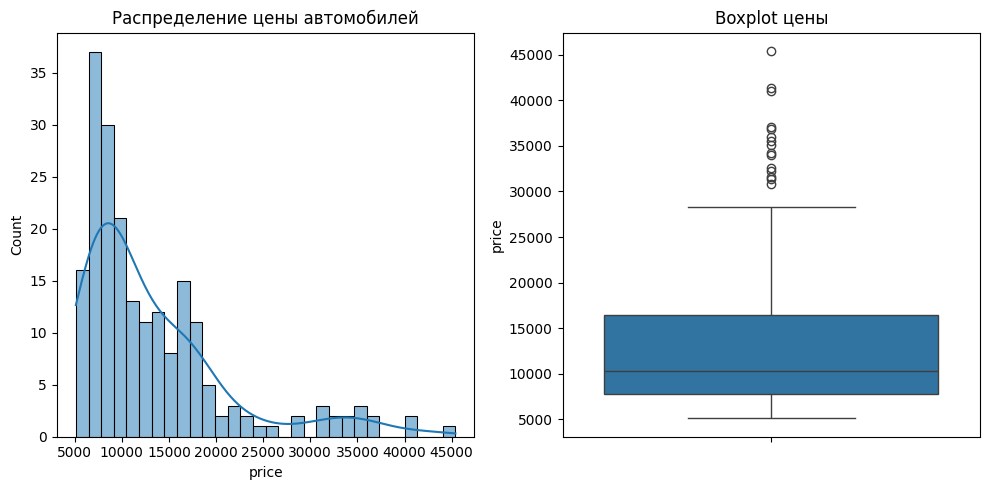

Средняя цена: $13276.71
Медианная цена: $10295.00


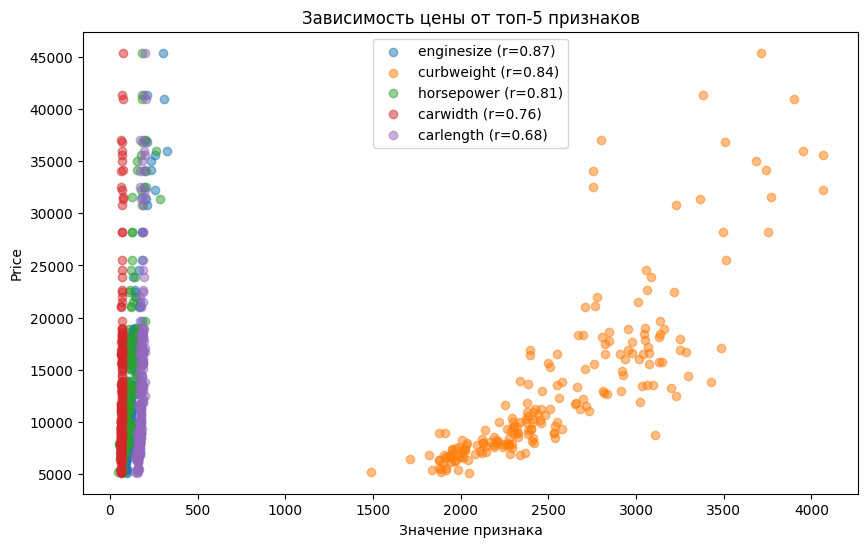

C:\Users\25\AppData\Local\Temp\ipykernel_4404\2981823963.py:85: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


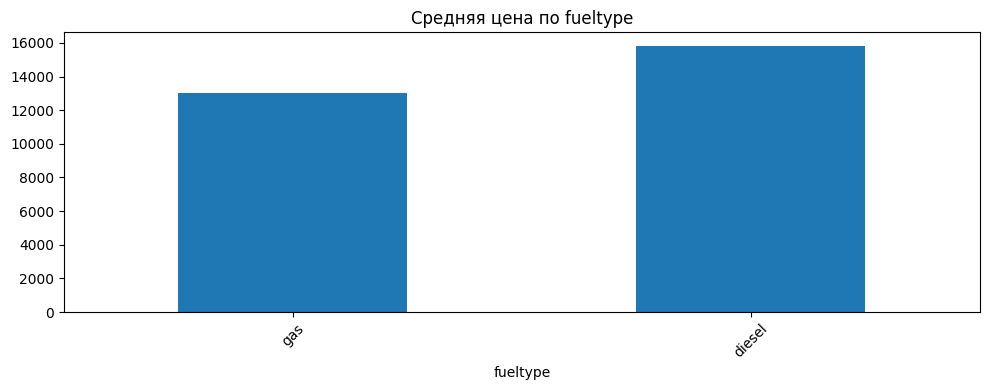

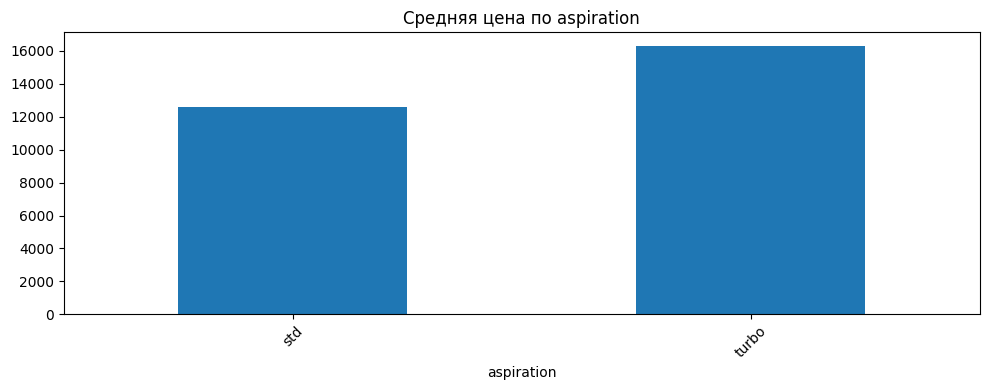

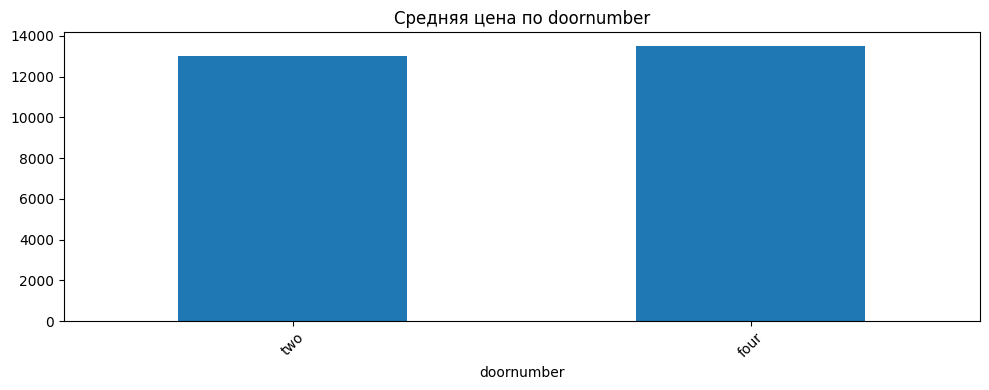

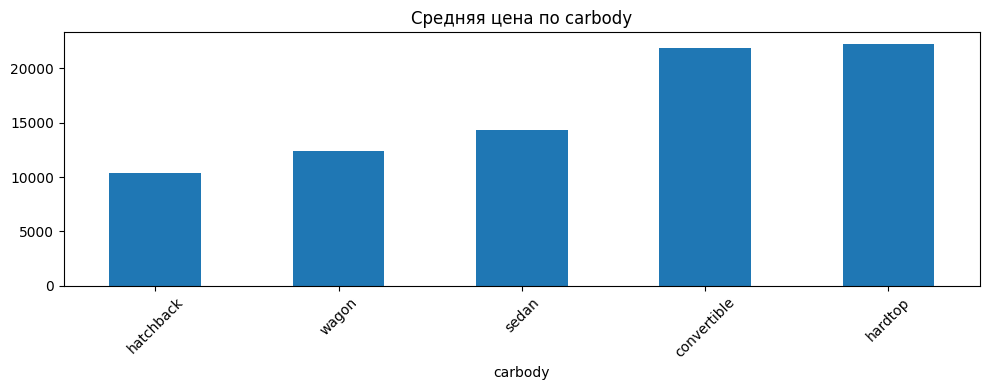

In [6]:
# %% [markdown]
# # 1. EDA - Исследовательский анализ данных
# ## Car Price Dataset

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.utils import set_seed

set_seed(42)

# %%
# Загрузка данных
df = pd.read_csv('../data/raw/CarPrice_Assignment.csv')
print(f"Размер: {df.shape}")
df.head()

# %%
# Информация о колонках
df.info()

# %%
# Статистика числовых признаков
df.describe()

# %%
# Проверка пропусков
df.isnull().sum()

# %%
# Проверка дубликатов
print(f"Дубликатов: {df.duplicated().sum()}")

# %%
# Распределение целевой переменной (price)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Распределение цены автомобилей')

plt.subplot(1,2,2)
sns.boxplot(y=df['price'])
plt.title('Boxplot цены')
plt.tight_layout()
plt.savefig('../report/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Средняя цена: ${df['price'].mean():.2f}")
print(f"Медианная цена: ${df['price'].median():.2f}")

# %%
# Корреляция числовых признаков с ценой
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'price' in numeric_cols:
    numeric_cols.remove('price')

correlations = []
for col in numeric_cols:
    corr = df['price'].corr(df[col])
    correlations.append((col, corr))

corr_df = pd.DataFrame(correlations, columns=['Feature', 'Correlation with Price'])
corr_df = corr_df.sort_values('Correlation with Price', ascending=False)
corr_df

# %%
# Топ-5 коррелирующих признаков
plt.figure(figsize=(10,6))
top_features = corr_df.head(5)['Feature'].tolist()
for col in top_features:
    plt.scatter(df[col], df['price'], alpha=0.5, label=f'{col} (r={df["price"].corr(df[col]):.2f})')
plt.xlabel('Значение признака')
plt.ylabel('Price')
plt.title('Зависимость цены от топ-5 признаков')
plt.legend()
plt.savefig('../report/top_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# Анализ категориальных признаков
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'CarName' in categorical_cols:
    categorical_cols.remove('CarName')
if 'car_ID' in categorical_cols:
    categorical_cols.remove('car_ID')

for col in categorical_cols[:4]:  # первые 4 для примера
    plt.figure(figsize=(10,4))
    df.groupby(col)['price'].mean().sort_values().plot(kind='bar')
    plt.title(f'Средняя цена по {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()